In [23]:
import torch
import librosa
import librosa.display
import matplotlib.pyplot as plt
import soundfile as sf
import os
import numpy as np

from src.model import AntiArtifactModel
from src.preprocess import AudioPreprocessor

In [24]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f"Using device: {device}")

model = AntiArtifactModel(embed_dim=128).to(device)

weights_path = os.path.join('weights', 'anti_artifact_model_final.pth')

model.load_state_dict(torch.load(weights_path, map_location=device))
model.eval()

processor = AudioPreprocessor(sample_rate=44100, n_fft=2048, hop_length=512)
print("model and preprocessor loaded and ready for evaluation")

Using device: mps
model and preprocessor loaded and ready for evaluation


In [25]:
artifacted_path = 'eval_data/sample_artifacted_target.wav'
reference_path = 'eval_data/sample_reference.wav'

artifacted_wav = processor.wav_to_tensors(artifacted_path)
reference_wav = processor.wav_to_tensors(reference_path)

min_len = min(artifacted_wav.shape[-1], reference_wav.shape[-1])
clean_primary_wav = artifacted_wav[:, :min_len]
reference_wav = reference_wav[:, :min_len]

print("song clips loaded.")



song clips loaded.


In [26]:
if artifacted_wav.dim() == 3:
    artifacted_wav = artifacted_wav.squeeze(0) # Drops batch dim if it exists
if reference_wav.dim() == 3:
    reference_wav = reference_wav.squeeze(0)

artifacted_wav = artifacted_wav.to(device)
reference_wav = reference_wav.to(device)

complex_artifacted = processor.waveform_to_complex_stft(artifacted_wav)
complex_reference = processor.waveform_to_complex_stft(reference_wav)

mag_artifacted = torch.abs(complex_artifacted).unsqueeze(0)
mag_reference = torch.abs(complex_reference).unsqueeze(0)

with torch.no_grad():
    predicted_mask = model(mag_artifacted, mag_reference)
    predicted_mag = mag_artifacted * predicted_mask

print("inference completed.")



inference completed.


/Users/jacobmitani/anaconda3/envs/native_env/lib/python3.11/site-packages/torch/functional.py:681: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [1, 254, 1025]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  return _VF.stft(  # type: ignore[attr-defined]


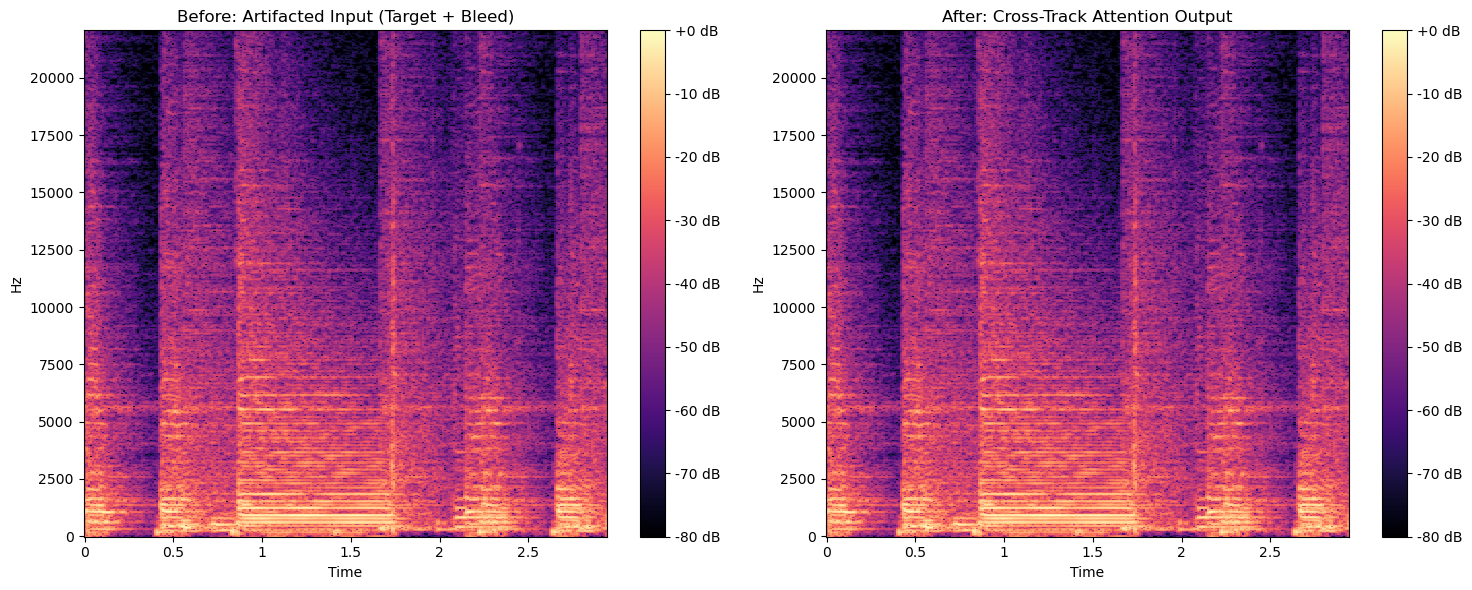

In [27]:
clean_mag = predicted_mag.squeeze().cpu().numpy()
original_mag = mag_artifacted.squeeze().cpu().numpy()

plt.figure(figsize=(15, 6))

#plot 1: prior to separation
plt.subplot(1, 2, 1)
librosa.display.specshow(librosa.amplitude_to_db(original_mag, ref=np.max), 
                         sr=processor.sample_rate, hop_length=processor.hop_length,
                         y_axis='hz', x_axis='time')
plt.title('Before: Artifacted Input (Target + Bleed)')
plt.colorbar(format='%+2.0f dB')

# Plot 2: After Separation
plt.subplot(1, 2, 2)
librosa.display.specshow(librosa.amplitude_to_db(clean_mag, ref=np.max), 
                         sr=processor.sample_rate, hop_length=processor.hop_length,
                         y_axis='hz', x_axis='time')
plt.title('After: Cross-Track Attention Output')
plt.colorbar(format='%+2.0f dB')

plt.tight_layout()
plt.show()

In [28]:
with torch.no_grad():
    clean_audio_tensor = processor.reconstruct_audio(
        complex_artifacted,
        predicted_mask
    )

clean_audio_np = clean_audio_tensor.squeeze().cpu().numpy()

#anti-clipping
max_amp = np.max(np.abs(clean_audio_np))
if max_amp > 1.0:
    print("Normalizing clipping audio")
    clean_audio_np = clean_audio_np / max_amp

output_path = 'eval_data/separated_output.wav'
sf.write(output_path, clean_audio_np, processor.sample_rate)

print(f"audio saved to: {output_path}")

Normalizing clipping audio
audio saved to: eval_data/separated_output.wav


/Users/jacobmitani/DSCI410/audio_separation_project/src/preprocess.py:67: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [1, 254, 2048]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  waveform = torch.istft(
